<a href="https://colab.research.google.com/github/Dfgr109109/proyecto/blob/main/Capitulo_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Considere la figura 6.1, tome una ecuación determinada, por ejemplo una raíz cúbica, o un seno, genere un data set con muchos valores. Con base en ese data set y utilizando una herramienta de ML, encuentre un modelo para el cálculo de la raíz cuadrada. Úselo con 10 ejemplos y compare los resultados con los que da la función del lenguaje.

In [1]:
# Paso 1: Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import math

# Paso 2: Generar dataset
X = np.random.uniform(0, 1000, 10000).reshape(-1, 1)
y = np.sqrt(X)

# Paso 3: Separar datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso 4: Crear modelo de regresión
model = LinearRegression()
model.fit(X_train, y_train)

# Paso 5: Predicción sobre 10 ejemplos nuevos
X_new = np.array([4, 9, 16, 25, 36, 49, 64, 81, 100, 121]).reshape(-1, 1)
y_pred = model.predict(X_new)

# Mostrar resultados
print("x\tML sqrt\t\tmath.sqrt")
for i in range(len(X_new)):
    print(f"{X_new[i][0]}\t{y_pred[i][0]:.4f}\t\t{math.sqrt(X_new[i][0]):.4f}")


x	ML sqrt		math.sqrt
4	8.5482		2.0000
9	8.6747		3.0000
16	8.8518		4.0000
25	9.0795		5.0000
36	9.3578		6.0000
49	9.6867		7.0000
64	10.0662		8.0000
81	10.4963		9.0000
100	10.9771		10.0000
121	11.5084		11.0000


# 2. Estudie el algoritmo SVM con todo detalle, mejore su documentación y con base en el haga cambios para una aplicación.

## Support Vector Machine (SVM) - Documentación resumida

SVM es un modelo de aprendizaje supervisado útil tanto para clasificación como para regresión. Su objetivo principal es encontrar el hiperplano que mejor separa las clases de entrenamiento.

### Ventajas:
- Funciona bien con espacios de alta dimensión.
- Eficaz en casos con margen de separación claro.
- Útil en problemas lineales y no lineales (gracias al uso de kernels).

### Parámetros importantes:
- **C**: penaliza errores (tradeoff entre margen ancho y error de clasificación).
- **kernel**: función que transforma los datos a espacios de mayor dimensión.
- **gamma**: controla la influencia de un solo punto (en kernels no lineales).

### Aplicaciones típicas:
- Detección de spam.
- Clasificación de imágenes.
- Diagnóstico médico.
- Reconocimiento de texto o voz.


In [3]:
# Paso 1: Librerías
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Paso 2: Cargar dataset de dígitos
digits = datasets.load_digits()
X = digits.data
y = digits.target

# Paso 3: Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Paso 4: Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Paso 5: Crear y entrenar SVM
svm = SVC(kernel='rbf', C=10, gamma=0.01)  # puedes probar otros kernels como 'linear'
svm.fit(X_train, y_train)

# Paso 6: Evaluar
y_pred = svm.predict(X_test)
print("🔍 Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Reporte de clasificación:\n", classification_report(y_test, y_pred))


🔍 Matriz de confusión:
 [[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  1  0  0  0  0  0 29  0]
 [ 0  0  0  1  0  0  0  0  1 38]]

📋 Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       1.00      1.00      1.00        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy       

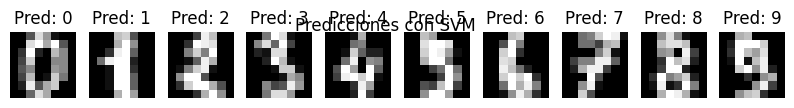

In [4]:
# Mostrar algunas predicciones
fig, axes = plt.subplots(1, 10, figsize=(10, 1))
for i in range(10):
    axes[i].imshow(digits.images[i], cmap='gray')
    axes[i].set_title(f"Pred: {svm.predict([X_scaled[i]])[0]}")
    axes[i].axis('off')
plt.suptitle("Predicciones con SVM")
plt.show()


# 3. Estudie el algoritmo de K- Nearest, con todo detalle mejore su documentación y con base en el haga cambios para una aplicación.

## K-Nearest Neighbors (KNN)

### Descripción:
KNN es un algoritmo supervisado que memoriza el conjunto de entrenamiento y lo utiliza directamente para predecir. Es simple, eficaz y no hace suposiciones sobre la distribución de los datos.

### Parámetros importantes:
- **k**: número de vecinos considerados (usualmente impar).
- **metric**: medida de distancia (`euclidean`, `manhattan`, etc.).
- **weights**: ponderación de los vecinos (`uniform` o `distance`).

### Ventajas:
- Muy simple de implementar.
- No necesita entrenamiento previo (lazy learner).
- Funciona bien con clases bien separadas.

### Desventajas:
- Lento con muchos datos.
- Sensible a la escala de los datos.
- Necesita una buena elección de `k`.

### Aplicaciones:
- Recomendadores.
- Clasificación de texto.
- Diagnóstico médico.
- Reconocimiento facial.


In [5]:
# Paso 1: Librerías
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Paso 2: Cargar datos
iris = load_iris()
X = iris.data
y = iris.target

# Paso 3: Escalado (muy importante para KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Paso 4: División de datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Paso 5: Crear modelo KNN
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

# Paso 6: Evaluación
y_pred = knn.predict(X_test)
print("🔍 Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Reporte de clasificación:\n", classification_report(y_test, y_pred))


🔍 Matriz de confusión:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

📋 Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [6]:
import numpy as np

# Probar con una nueva muestra
sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # ejemplo real
sample_scaled = scaler.transform(sample)
prediction = knn.predict(sample_scaled)
print(f"\n🌸 Clase predicha: {iris.target_names[prediction[0]]}")



🌸 Clase predicha: setosa


# 4.  Estudie el algoritmo de árboles de decisión, con todo detalle mejore su documentación y con base en el haga cambios para una aplicación.

## Árboles de Decisión

### Descripción:
Un árbol de decisión divide los datos en subconjuntos basados en reglas condicionales ("¿La característica X es mayor a un valor Y?"). Cada división intenta maximizar la pureza de las clases (minimizar la mezcla).

### Ventajas:
- Muy fácil de entender y visualizar.
- No requiere normalización o escalado.
- Funciona bien con datos categóricos y numéricos.
- Puede manejar relaciones no lineales.

### Desventajas:
- Tiende a sobreajustar (overfitting), especialmente árboles profundos.
- Sensible a pequeñas variaciones en los datos.
- No generaliza bien si no se poda o regulariza.

### Criterios de división:
- **Gini Impurity**: mide la "mezcla" de clases.
- **Entropy / Information Gain**: mide la ganancia de información.
- **MSE** (para regresión).

### Parámetros clave:
- **max_depth**: profundidad máxima del árbol.
- **min_samples_split**: mínimo de muestras para dividir un nodo.
- **criterion**: ‘gini’, ‘entropy’, ‘log_loss’ o ‘squared_error’ (regresión).

### Aplicaciones:
- Diagnóstico médico.
- Clasificación de clientes.
- Sistemas de recomendación.
- Créditos y préstamos.


In [7]:
# Paso 1: Librerías
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt

# Paso 2: Cargar datos
wine = load_wine()
X = wine.data
y = wine.target

# Paso 3: Escalado no es necesario, pero se puede usar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Paso 4: División de datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Paso 5: Crear y entrenar el modelo
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Paso 6: Evaluación
y_pred = clf.predict(X_test)
print("🔍 Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Reporte de clasificación:\n", classification_report(y_test, y_pred))


🔍 Matriz de confusión:
 [[13  1  0]
 [ 0 14  0]
 [ 1  0  7]]

📋 Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



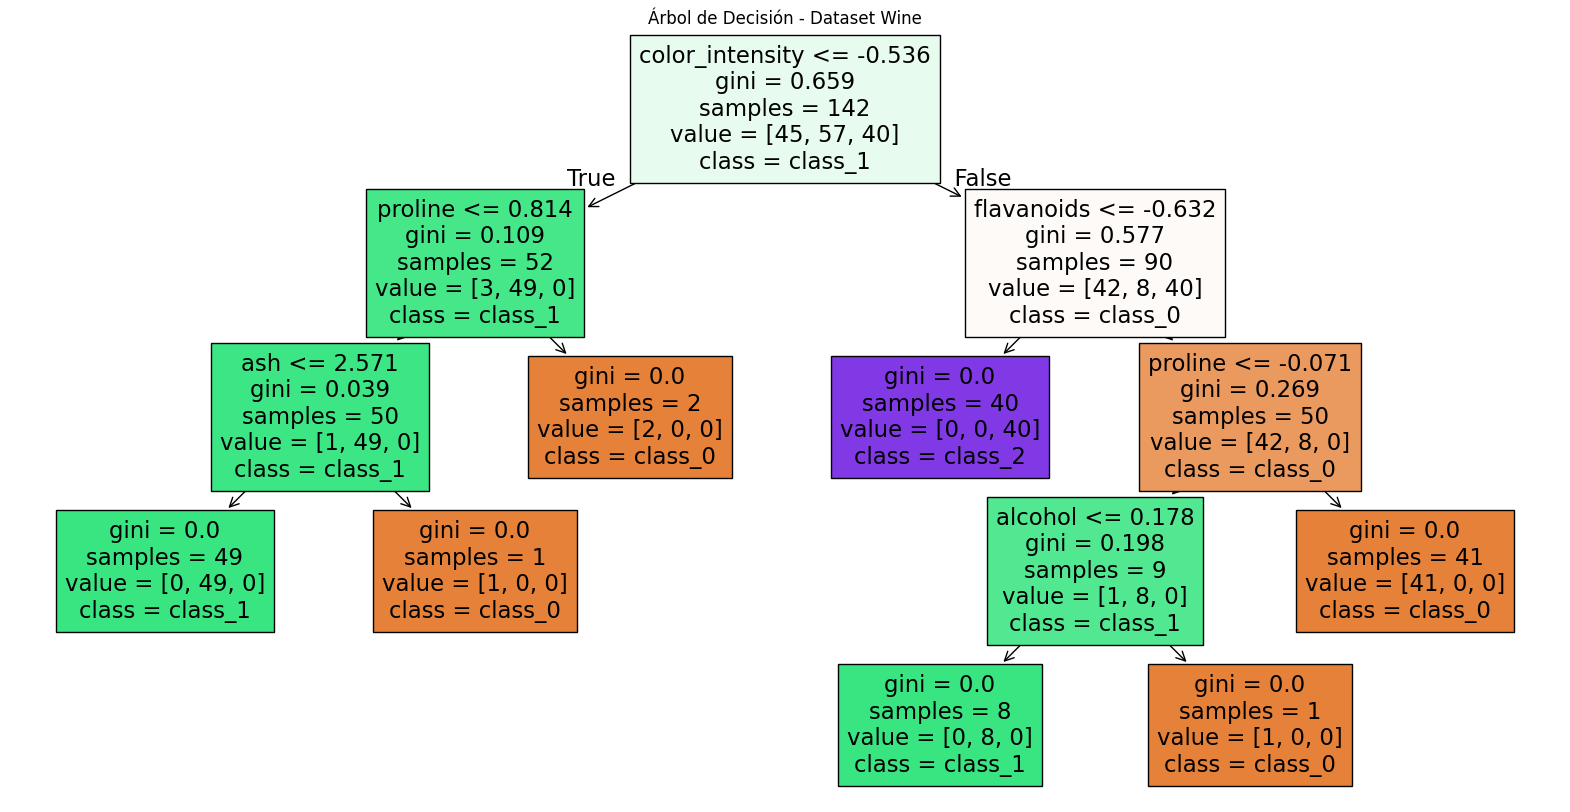

In [8]:
# Visualizar el árbol
plt.figure(figsize=(20, 10))
tree.plot_tree(clf, filled=True, feature_names=wine.feature_names, class_names=wine.target_names)
plt.title("Árbol de Decisión - Dataset Wine")
plt.show()
